In [132]:
#读取数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
df=pd.read_csv(r"D:\HuaweiMoveData\Users\魏紫怡\Desktop\KAG_conversion_data.csv")
df.head(20)

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1
5,708820,916,103929,30-34,M,29,1915,0,0.00,1,1
6,708889,916,103940,30-34,M,15,15615,3,4.77,1,0
7,708895,916,103941,30-34,M,16,10951,1,1.27,1,1
8,708953,916,103951,30-34,M,27,2355,1,1.50,1,0
9,708958,916,103952,30-34,M,28,9502,3,3.16,1,0


# 数据清洗

# 缺失值

In [45]:
#判断缺失值，读取字段类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB


# 更变字段类型

In [46]:
# 转分类变量
df[['xyz_campaign_id','age', 'gender', 'interest']] = df[[ 'xyz_campaign_id','age', 'gender', 'interest']].astype('category')
#转字符串
df[['ad_id', 'fb_campaign_id']] = df[['ad_id', 'fb_campaign_id']].astype('str')
#不变
#df[['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']] = df[['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']].apply(pd.to_numeric)

print(df.dtypes)

ad_id                    object
xyz_campaign_id        category
fb_campaign_id           object
age                    category
gender                 category
interest               category
Impressions               int64
Clicks                    int64
Spent                   float64
Total_Conversion          int64
Approved_Conversion       int64
dtype: object


# 判断重复值

In [47]:
df.nunique()

ad_id                  1143
xyz_campaign_id           3
fb_campaign_id          691
age                       4
gender                    2
interest                 40
Impressions            1130
Clicks                  183
Spent                   869
Total_Conversion         32
Approved_Conversion      16
dtype: int64

In [48]:
#数据完全一摸一样的
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


In [51]:
#删除除ad_id外所有相同的列
df=df.drop_duplicates(subset=['xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest', 'Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion'], keep="first")
df

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.430000,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.820000,2,0
2,708771,916,103920,30-34,M,20,693,0,0.000000,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.250000,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.290000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,1178,179977,45-49,F,109,1129773,252,358.189997,13,2
1139,1314411,1178,179978,45-49,F,110,637549,120,173.880003,3,0
1140,1314412,1178,179979,45-49,F,111,151531,28,40.289999,2,0
1141,1314414,1178,179981,45-49,F,113,790253,135,198.710000,8,2


In [31]:
dup = df[df.duplicated(subset=['xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest'], keep=False)]

# 按五列排序方便查看
dup = dup.sort_values(['xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest'])
display(dup)

#print(dup.to_string(index=False))

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
3,708815,916,103928,30-34,M,28,4259,1,1.250000,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.290000,1,1
12,709038,916,103965,30-34,M,16,5117,0,0.000000,1,0
13,709040,916,103965,30-34,M,16,5120,0,0.000000,1,0
20,709320,916,104012,35-39,M,15,1422,0,0.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1042,1122308,1178,144741,45-49,F,63,427772,117,159.299999,3,1
1043,1122310,1178,144742,45-49,F,64,536457,136,193.659999,2,1
1044,1122311,1178,144742,45-49,F,64,179894,43,66.839999,2,0
1045,1122312,1178,144742,45-49,F,64,479882,131,178.670001,6,0


# 判断异常值

In [11]:
#描述性统计
df.describe()

,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,1.867321e+05,33.390201,51.360656,2.855643,0.944007
std,3.127622e+05,56.892438,86.908418,4.483593,1.737708
min,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,3.052003e+06,421.000000,639.949998,60.000000,21.000000


In [58]:
#判断浏览数小于点击数
result1=df[df['Impressions']<df['Clicks']]
result1

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion


In [61]:
#判断点击数小于转化数
result2=df[df['Clicks']<df['Total_Conversion']]
result2
#存在浏览归因

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
5,708820,916,103929,30-34,M,29,1915,0,0.00,1,1
10,708979,916,103955,30-34,M,31,1224,0,0.00,1,0
11,709023,916,103962,30-34,M,7,735,0,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
851,1121791,1178,144655,30-34,F,23,6838,0,0.00,1,0
880,1121846,1178,144664,30-34,F,32,8350,0,0.00,1,0
882,1121854,1178,144666,30-34,F,63,8587,0,0.00,1,0
894,1121873,1178,144669,30-34,F,2,5264,0,0.00,1,0


In [65]:
#四分位法
num_cols = ['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, 异常值={len(outliers)}条 ({len(outliers)/len(df)*100:.2f}%)")

Impressions: Q1=6545.25, Q3=221806.0, IQR=215260.75, 异常值=123条 (10.77%)
Clicks: Q1=1.0, Q3=37.75, IQR=36.75, 异常值=127条 (11.12%)
Spent: Q1=1.4800000265, Q3=60.112499742500006, IQR=58.632499716000005, 异常值=125条 (10.95%)
Total_Conversion: Q1=1.0, Q3=3.0, IQR=2.0, 异常值=105条 (9.19%)
Approved_Conversion: Q1=0.0, Q3=1.0, IQR=1.0, 异常值=95条 (8.32%)


D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0, flags=flags)
D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0, flags=flags)


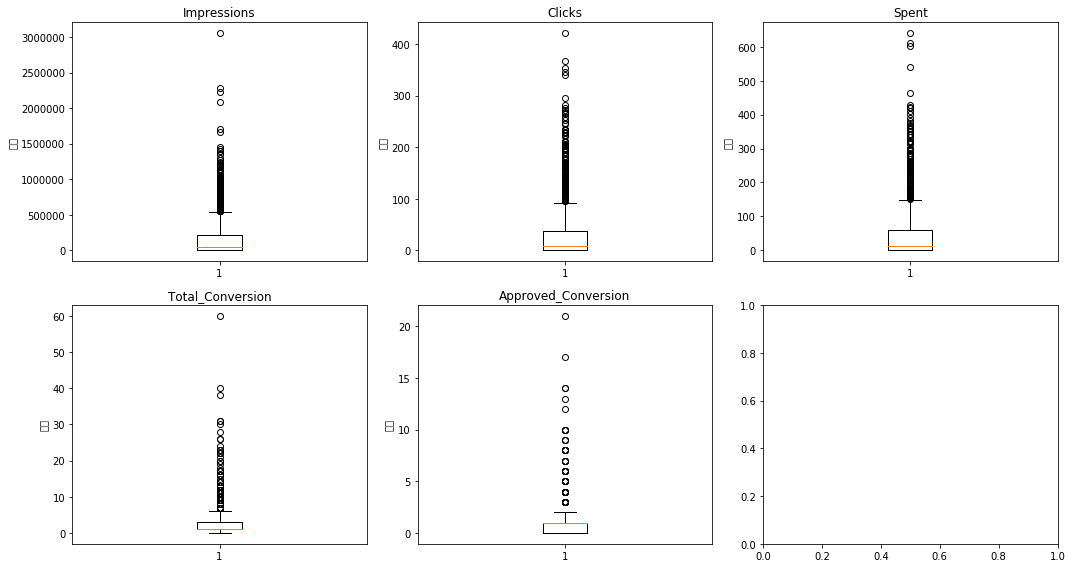

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('数值')

plt.tight_layout()
plt.show()

In [70]:
#运用Z-score检测异常值
from scipy import stats
num_cols = ['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']
for col in num_cols:
    z = stats.zscore(df[col])
    outliers = df[abs(z) > 3]
    print(f"{col}: 异常值 {len(outliers)} 条 ({len(outliers)/len(df)*100:.2f}%)")

Impressions: 异常值 23 条 (2.01%)
Clicks: 异常值 33 条 (2.89%)
Spent: 异常值 32 条 (2.80%)
Total_Conversion: 异常值 26 条 (2.28%)
Approved_Conversion: 异常值 22 条 (1.93%)


# 业务分析

# 整体效果

In [136]:
#核心指标
total_impressions = df['Impressions'].sum()
total_clicks = df['Clicks'].sum()
total_conversion = df['Total_Conversion'].sum()
total_approved = df['Approved_Conversion'].sum()
total_spent = df['Spent'].sum()

print(f"CTR: {total_clicks / total_impressions * 100:.4f}%")
print(f"CVR: {total_approved / total_clicks * 100:.2f}%")
print(f"CPA: ${total_spent / total_approved:.2f}")
print(f"总曝光: {total_impressions:,}")
print(f"总点击: {total_clicks:,}")
print(f"总转化: {total_conversion:,}")
print(f"总有效转化: {total_approved:,}")
print(f"总支出: {total_spent:.2f}")

CTR: 0.0179%
CVR: 2.83%
CPA: $54.41
总曝光: 213,434,828
总点击: 38,165
总转化: 3,264
总有效转化: 1,079
总支出: 58705.23


# 各维度分析

In [137]:
#从活动的维度分析
campaign = df.groupby('xyz_campaign_id').agg(
    花费=('Spent', 'sum'),
    曝光=('Impressions', 'sum'),
    点击=('Clicks', 'sum'),
    下单=('Total_Conversion', 'sum'),
    购买=('Approved_Conversion', 'sum')
)

campaign['CTR'] = campaign['点击'] / campaign['曝光'] * 100
campaign['CVR'] = campaign['购买'] / campaign['点击'] * 100
campaign['CPA'] = campaign['花费'] / campaign['购买']

# 新增占比列
total_spent = campaign['花费'].sum()
total_approved = campaign['购买'].sum()

campaign['花费占比'] = campaign['花费'] / total_spent * 100
campaign['购买占比'] = campaign['购买'] / total_approved * 100

# 重新排序列
campaign = campaign[['花费', '花费占比', '曝光', '点击', '下单', '购买', '购买占比', 'CTR', 'CVR', 'CPA']]

display(campaign)

,花费,花费占比,曝光,点击,下单,购买,购买占比,CTR,CVR,CPA
xyz_campaign_id,,,,,,,,,,
916,149.710001,0.255020,482925,113,58,24,2.224282,0.023399,21.238938,6.237917
936,2893.369999,4.928641,8128187,1984,537,183,16.960148,0.024409,9.223790,15.810765
1178,55662.149959,94.816339,204823716,36068,2669,872,80.815570,0.017609,2.417656,63.832741


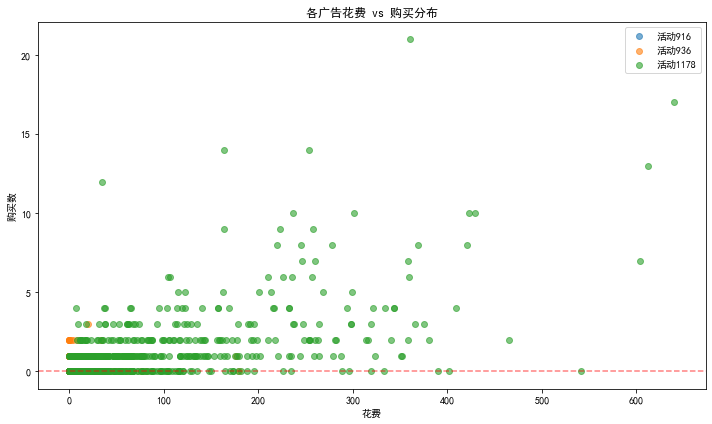

In [147]:
# 2. 各活动花费 vs 购买（散点图）
plt.figure(figsize=(10,6))
for campaign in df['xyz_campaign_id'].unique():
    data = df[df['xyz_campaign_id'] == campaign]
    plt.scatter(data['Spent'], data['Approved_Conversion'], 
                label=f'活动{campaign}', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('花费')
plt.ylabel('购买数')
plt.title('各广告花费 vs 购买分布')
plt.legend()
plt.tight_layout()
plt.show()

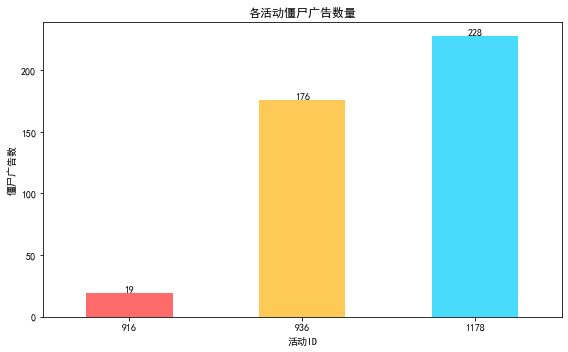

In [148]:
#1. 各活动僵尸广告数量（柱状图）
zombie = df[(df['Spent'] > 0) & (df['Approved_Conversion'] == 0)]
zombie_count = zombie.groupby('xyz_campaign_id').size()

plt.figure(figsize=(8,5))
zombie_count.plot(kind='bar', color=['#ff6b6b', '#feca57', '#48dbfb'])
plt.title('各活动僵尸广告数量')
plt.xlabel('活动ID')
plt.ylabel('僵尸广告数')
plt.xticks(rotation=0)
for i, v in enumerate(zombie_count.values):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.tight_layout()
plt.show()

In [149]:
zombie = df[(df['Spent'] > 0) & (df['Approved_Conversion'] == 0)]
print(f"僵尸广告: {len(zombie)} 个，浪费 ${zombie['Spent'].sum():.2f}")
print(zombie.groupby('xyz_campaign_id')['Spent'].sum())

僵尸广告: 423 个，浪费 $14754.42
xyz_campaign_id
916        74.310001
936      1910.420000
1178    12769.690008
Name: Spent, dtype: float64


In [139]:
#从年龄的维度分析
age = df.groupby('age').agg(
    花费=('Spent', 'sum'),
    曝光=('Impressions', 'sum'),
    点击=('Clicks', 'sum'),
    下单=('Total_Conversion', 'sum'),
    购买=('Approved_Conversion', 'sum')
)
age['CTR'] = age['点击'] / age['曝光'] * 100
age['CVR'] = age['购买'] / age['点击'] * 100
age['CPA'] = age['花费'] / age['购买']
age['花费占比'] = age['花费'] / age['花费'].sum() * 100
age['购买占比'] = age['购买'] / age['购买'].sum() * 100
age = age[['花费', '花费占比', '曝光', '点击', '下单', '购买', '购买占比', 'CTR', 'CVR', 'CPA']]
print('=== 年龄维度 ===')
display(age)

=== 年龄维度 ===


,花费,花费占比,曝光,点击,下单,购买,购买占比,CTR,CVR,CPA
age,,,,,,,,,,
30-34,15252.399986,25.981331,67993019,9483,1431,494,45.783133,0.013947,5.209322,30.875304
35-39,11112.429994,18.929199,42104644,7094,626,207,19.184430,0.016848,2.917959,53.683237
40-44,11589.729981,19.742244,39604307,7736,523,170,15.755329,0.019533,2.197518,68.174882
45-49,20750.669997,35.347225,63732858,13852,684,208,19.277108,0.021734,1.501588,99.762837


In [140]:
#从性别维度分析
gender = df.groupby('gender').agg(
    花费=('Spent', 'sum'),
    曝光=('Impressions', 'sum'),
    点击=('Clicks', 'sum'),
    下单=('Total_Conversion', 'sum'),
    购买=('Approved_Conversion', 'sum')
)
gender['CTR'] = gender['点击'] / gender['曝光'] * 100
gender['CVR'] = gender['购买'] / gender['点击'] * 100
gender['CPA'] = gender['花费'] / gender['购买']
gender['花费占比'] = gender['花费'] / gender['花费'].sum() * 100
gender['购买占比'] = gender['购买'] / gender['购买'].sum() * 100
gender = gender[['花费', '花费占比', '曝光', '点击', '下单', '购买', '购买占比', 'CTR', 'CVR', 'CPA']]
print('=== 性别维度 ===')
display(gender)


=== 性别维度 ===


,花费,花费占比,曝光,点击,下单,购买,购买占比,CTR,CVR,CPA
gender,,,,,,,,,,
F,34502.619963,58.772651,114862847,23878,1644,495,45.875811,0.020788,2.073038,69.702263
M,24202.609995,41.227349,98571981,14287,1620,584,54.124189,0.014494,4.087632,41.442825


In [144]:
# 兴趣维度（按购买降序取前10）
interest = df.groupby('interest').agg(
    花费=('Spent', 'sum'),
    曝光=('Impressions', 'sum'),
    点击=('Clicks', 'sum'),
    下单=('Total_Conversion', 'sum'),
    购买=('Approved_Conversion', 'sum')
)
interest['CTR'] = interest['点击'] / interest['曝光'] * 100
interest['CVR'] = interest['购买'] / interest['点击'] * 100
interest['CPA'] = interest['花费'] / interest['购买']
interest['花费占比'] = interest['花费'] / interest['花费'].sum() * 100
interest['购买占比'] = interest['购买'] / interest['购买'].sum() * 100
interest = interest[['花费', '花费占比', '曝光', '点击', '下单', '购买', '购买占比', 'CTR', 'CVR', 'CPA']]
interest = interest.sort_values('CPA', ascending=True)
print('=== 兴趣维度 TOP10（按购买） ===')
display(interest)

=== 兴趣维度 TOP10（按购买） ===


,花费,花费占比,曝光,点击,下单,购买,购买占比,CTR,CVR,CPA
interest,,,,,,,,,,
31,299.099999,0.509495,1075312,195,33,16,1.482854,0.018134,8.205128,18.693750
36,205.740000,0.350463,922928,128,28,10,0.926784,0.013869,7.812500,20.574000
2,503.450005,0.857590,1727646,311,40,19,1.760890,0.018001,6.109325,26.497369
65,542.010001,0.923274,1737547,372,33,19,1.760890,0.021409,5.107527,28.526842
101,757.689998,1.290669,2960453,524,71,25,2.316960,0.017700,4.770992,30.307600
21,824.209999,1.403981,2833321,512,70,27,2.502317,0.018071,5.273438,30.526296
102,215.069999,0.366356,1160953,150,14,7,0.648749,0.012920,4.666667,30.724286
112,483.799999,0.824117,2324572,339,53,15,1.390176,0.014583,4.424779,32.253333
7,648.929999,1.105404,2612839,410,59,19,1.760890,0.015692,4.634146,34.154210


# 交叉分析

Text(0, 0.5, '年龄')

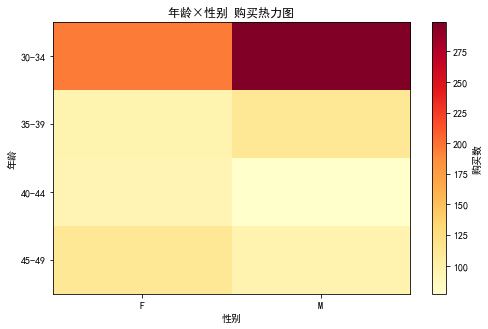

In [160]:
# 4. 年龄+性别 购买热力图
age_gender = df.groupby(['age', 'gender'])['Approved_Conversion'].sum().unstack()

plt.figure(figsize=(8,5))
plt.imshow(age_gender.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='购买数')
plt.xticks(range(len(age_gender.columns)), age_gender.columns)
plt.yticks(range(len(age_gender.index)), age_gender.index)
plt.title('年龄×性别 购买热力图')
plt.xlabel('性别')
plt.ylabel('年龄')

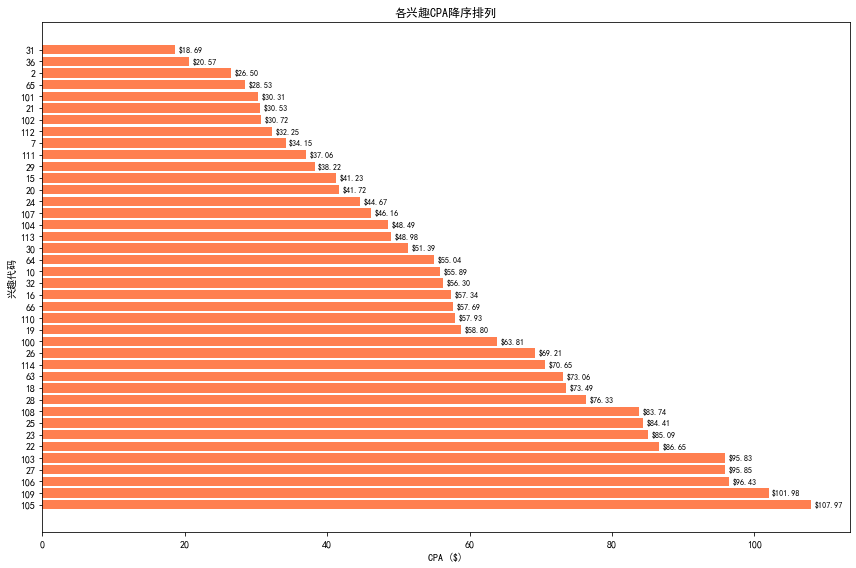

In [170]:
interest = df.groupby('interest').agg(
    购买=('Approved_Conversion', 'sum'),
    花费=('Spent', 'sum')
)
interest['CPA'] = interest['花费'] / interest['购买']
interest = interest[interest['购买'] > 0]
interest = interest.sort_values('CPA', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(interest.index.astype(str), interest['CPA'], color='coral')
plt.xlabel('CPA ($)')
plt.ylabel('兴趣代码')
plt.title('各兴趣CPA降序排列')
for i, v in enumerate(interest['CPA']):
    plt.text(v + 0.5, i, f'${v:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# 漏斗分析

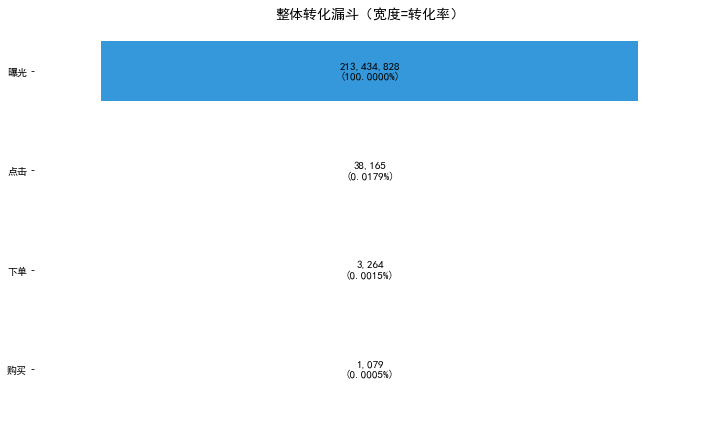

In [158]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

#df = pd.read_csv(r"D:\HuaweiMoveData\Users\魏紫怡\Desktop\conversion_data.csv")

stages = ['曝光', '点击', '下单', '购买']
values = [
    df['Impressions'].sum(),
    df['Clicks'].sum(),
    df['Total_Conversion'].sum(),
    df['Approved_Conversion'].sum()
]

fig, ax = plt.subplots(figsize=(10, 6))

max_val = max(values)
norm_values = [v / max_val for v in values]
y_pos = range(len(stages))[::-1]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for i, (y, v, nv) in enumerate(zip(y_pos, values, norm_values)):
    width = nv * 0.8
    left = (1 - width) / 2
    ax.barh(y, width, left=left, color=colors[i], height=0.6)
    
    pct = v / values[0] * 100
    label = f'{v:,}\n({pct:.4f}%)'
    ax.text(0.5, y, label, ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

#for i in range(1, len(values)):
#    if values[i-1] > 0:
#        loss = (1 - values[i] / values[i-1]) * 100
#        ax.text(0.95, i, f'↓{loss:.4f}%', ha='right', va='center', fontsize=10, color='red')

ax.set_title('整体转化漏斗（宽度=转化率）', fontsize=14)
plt.tight_layout()
plt.show()

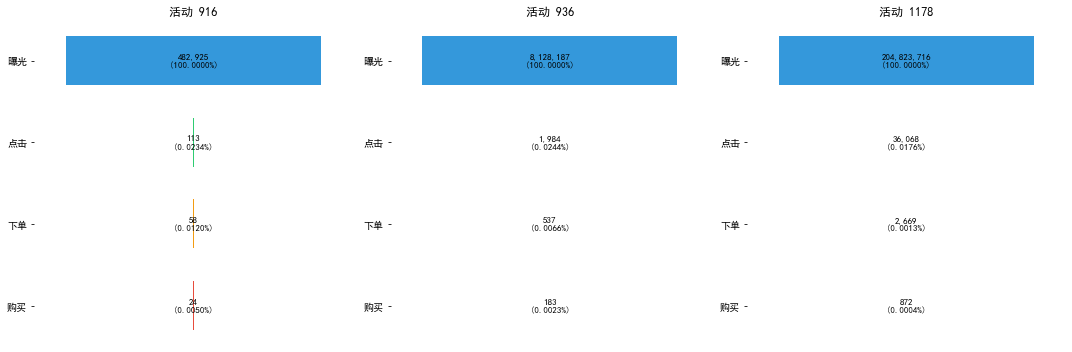

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

#df = pd.read_csv(r"D:\HuaweiMoveData\Users\魏紫怡\Desktop\conversion_data.csv")

stages = ['曝光', '点击', '下单', '购买']
campaigns = df['xyz_campaign_id'].unique()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, campaign in enumerate(campaigns):
    data = df[df['xyz_campaign_id'] == campaign]
    values = [
        data['Impressions'].sum(),
        data['Clicks'].sum(),
        data['Total_Conversion'].sum(),
        data['Approved_Conversion'].sum()
    ]
    
    max_val = max(values)
    norm_values = [v / max_val for v in values]
    
    y_pos = range(len(stages))[::-1]
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    
    for i, (y, v, nv) in enumerate(zip(y_pos, values, norm_values)):
        width = nv * 0.8
        left = (1 - width) / 2
        axes[idx].barh(y, width, left=left, color=colors[i], height=0.6)
        
        pct = v / values[0] * 100
        label = f'{v:,}\n({pct:.4f}%)'
        axes[idx].text(0.5, y, label, ha='center', va='center', fontsize=9, fontweight='bold')
    
    axes[idx].set_title(f'活动 {campaign}', fontsize=12)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(stages)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_xticks([])
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].spines['bottom'].set_visible(False)
    axes[idx].spines['left'].set_visible(False)
    
#    for i in range(1, len(values)):
#        if values[i-1] > 0:
#            loss = (1 - values[i] / values[i-1]) * 100
#            axes[idx].text(0.95, i, f'↓{loss:.4f}%', ha='right', va='center', fontsize=8, color='red')

plt.tight_layout()
plt.show()